# Jaccard Dissimilarity (Asymmetric Binary)

- Use only asymmetric attributes: `Fever`, `Cough`, `Test-1`, `Test-2`, `Test-3`, `Test-4`.
- Convert `Y` and `P` to `1`; convert `N` and `A` to `0`.
- Exclude `Gender` because it is symmetric.

Jaccard dissimilarity is computed as:

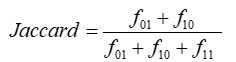

In [2]:
from itertools import combinations

# Keep only asymmetric attributes (exclude Gender).
attributes = ["Fever", "Cough", "Test-1", "Test-2", "Test-3", "Test-4"]

raw_data = {
    "Jack": {
        "Gender": "M",
        "Fever": "Y",
        "Cough": "N",
        "Test-1": "P",
        "Test-2": "N",
        "Test-3": "N",
        "Test-4": "A",
    },
    "Mary": {
        "Gender": "F",
        "Fever": "Y",
        "Cough": "N",
        "Test-1": "P",
        "Test-2": "A",
        "Test-3": "P",
        "Test-4": "N",
    },
    "Jim": {
        "Gender": "M",
        "Fever": "Y",
        "Cough": "P",
        "Test-1": "N",
        "Test-2": "N",
        "Test-3": "N",
        "Test-4": "A",
    },
}

def to_binary(value):
    return 1 if value in {"Y", "P"} else 0

def binary_vector(record):
    return [to_binary(record[attr]) for attr in attributes]

def jaccard_dissimilarity(x, y):
    f11 = sum(1 for a, b in zip(x, y) if a == 1 and b == 1)
    f10 = sum(1 for a, b in zip(x, y) if a == 1 and b == 0)
    f01 = sum(1 for a, b in zip(x, y) if a == 0 and b == 1)
    
    denominator = f11 + f10 + f01
    if denominator == 0:
        return 0.0
    return (f10 + f01) / denominator

binary_data = {name: binary_vector(record) for name, record in raw_data.items()}

for left_name, right_name in combinations(binary_data, 2):
    d = jaccard_dissimilarity(binary_data[left_name], binary_data[right_name])
    print(f"({left_name}, {right_name}) = {d:.2f}")

(Jack, Mary) = 0.33
(Jack, Jim) = 0.67
(Mary, Jim) = 0.75
